In [8]:
import tensorflow as tf
import pathlib
import matplotlib.pyplot as plt

# 获取数据集


In [2]:
traindir = 'hotdog/train'
testdir ='hotdog/test'

In [3]:
image_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1/255.)

In [4]:
# 获取训练集数据
train_data_gen = image_gen.flow_from_directory(traindir,batch_size=32,target_size=(224,224),shuffle=True)

Found 2000 images belonging to 2 classes.


In [5]:
# 获取测试集数据
test_data_gen = image_gen.flow_from_directory(testdir,batch_size=32,target_size=(224,224),shuffle=True)

Found 800 images belonging to 2 classes.


In [6]:
image,label = next(train_data_gen)

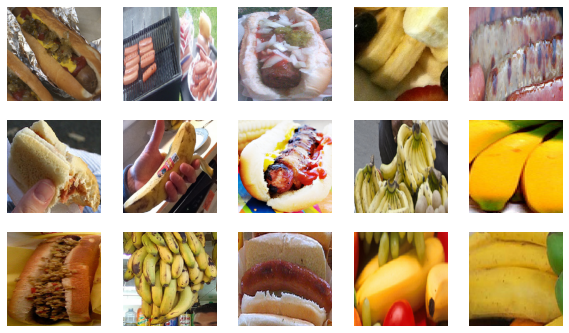

In [9]:
plt.figure(figsize=(10,10))
for n in range(15):
    ax = plt.subplot(5,5,n+1)
    plt.imshow(image[n])
    plt.axis('off')

# 模型构建与训练

In [10]:
ResNet50 = tf.keras.applications.ResNet50(weights='imagenet',input_shape=(224,224,3))
for layer in ResNet50.layers:
    layer.trainable=False
net = tf.keras.models.Sequential()
net.add(ResNet50)
net.add(tf.keras.layers.Flatten())
net.add(tf.keras.layers.Dense(2,activation="sigmoid"))

In [11]:
# 模型编译
net.compile(optimizer='adam',loss=tf.keras.losses.binary_crossentropy,metrics=["accuracy"])

In [12]:
# 模型训练
net.fit(train_data_gen,steps_per_epoch=10,epochs=3,batch_size=32,validation_data=test_data_gen,validation_steps=10)

Epoch 1/3
10/10 [==============================] - 28s 3s/step - loss: 0.6930 - accuracy: 0.5230 - val_loss: 0.6933 - val_accuracy: 0.4938
Epoch 2/3
10/10 [==============================] - 29s 3s/step - loss: 0.6927 - accuracy: 0.5312 - val_loss: 0.6923 - val_accuracy: 0.5469
Epoch 3/3
10/10 [==============================] - 31s 3s/step - loss: 0.6929 - accuracy: 0.5164 - val_loss: 0.6932 - val_accuracy: 0.5031
